In [1]:
#importing necesssary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#loading the dataset
df = pd.read_csv('CKD.csv')
#shape of dataset
print("Shape of Dataset:", df.shape)
df.head()

Shape of Dataset: (1659, 54)


,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,...,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,...,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,...,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,...,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1,Confidential
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,...,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1,Confidential


## Data Cleaning

In [2]:
#checking for missing values
miss_perc = df.isnull().mean().sort_values(ascending=False)
miss_perc[miss_perc>0] #show only columns with missing data

Series([], dtype: float64)

## Data types and Initial Sanity Check

In [3]:
#checking data types
df.dtypes.value_counts()

float64    30
int64      23
object      1
Name: count, dtype: int64

In [4]:
#describe numeric columns for sanity checks
df.describe()

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis
count,1659.000000,1659.000000,1659.000000,1659.00000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,...,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000
mean,830.000000,54.441230,0.515371,0.71308,0.977697,1.693189,27.620049,0.292948,9.969831,5.024247,...,3.525510,5.054869,49.730659,0.044002,0.103074,0.197107,2.000336,4.947788,5.144973,0.918626
std,479.056364,20.549757,0.499914,1.00043,0.776686,0.910611,7.288670,0.455252,5.798787,2.866274,...,2.026131,2.880460,27.827593,0.205162,0.304147,0.397934,1.141635,2.869959,2.901138,0.273492
min,1.000000,20.000000,0.000000,0.00000,0.000000,0.000000,15.033888,0.000000,0.021740,0.001186,...,0.006327,0.013697,0.087256,0.000000,0.000000,0.000000,0.001082,0.005392,0.004436,0.000000
25%,415.500000,36.000000,0.000000,0.00000,0.000000,1.000000,21.471449,0.000000,5.051156,2.555038,...,1.820793,2.532867,26.991708,0.000000,0.000000,0.000000,1.005802,2.498119,2.569561,1.000000
50%,830.000000,54.000000,1.000000,0.00000,1.000000,2.000000,27.652077,0.000000,9.951503,5.072395,...,3.572522,5.087086,48.970075,0.000000,0.000000,0.000000,2.040635,4.974069,5.182949,1.000000
75%,1244.500000,72.000000,1.000000,1.00000,2.000000,2.000000,34.015849,1.000000,14.967100,7.460563,...,5.254956,7.552093,73.913997,0.000000,0.000000,0.000000,2.947213,7.499783,7.733253,1.000000
max,1659.000000,90.000000,1.000000,3.00000,2.000000,3.000000,39.993532,1.000000,19.992713,9.998167,...,6.984636,9.998313,99.987510,1.000000,1.000000,1.000000,3.999469,9.992345,9.993754,1.000000


In [5]:
# Look at min/max values of all numeric columns
df.describe().T[['min', 'max']]

,min,max
PatientID,1.000000,1659.000000
Age,20.000000,90.000000
Gender,0.000000,1.000000
Ethnicity,0.000000,3.000000
SocioeconomicStatus,0.000000,2.000000
EducationLevel,0.000000,3.000000
BMI,15.033888,39.993532
Smoking,0.000000,1.000000
AlcoholConsumption,0.021740,19.992713
PhysicalActivity,0.001186,9.998167


## EDA: 1. Target Distribution

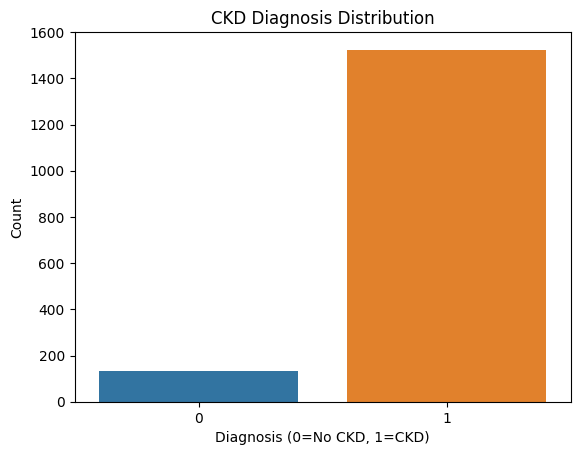

Diagnosis
1    91.9%
0     8.1%
Name: proportion, dtype: object

In [6]:
#plot class distribution
sns.countplot(data=df, x='Diagnosis')
plt.title("CKD Diagnosis Distribution")
plt.xlabel("Diagnosis (0=No CKD, 1=CKD)")
plt.ylabel("Count")
plt.show()

#percentage
df['Diagnosis'].value_counts(normalize=True).map("{:.1%}".format)

## EDA: 2. Feature Impact on Diagnosis

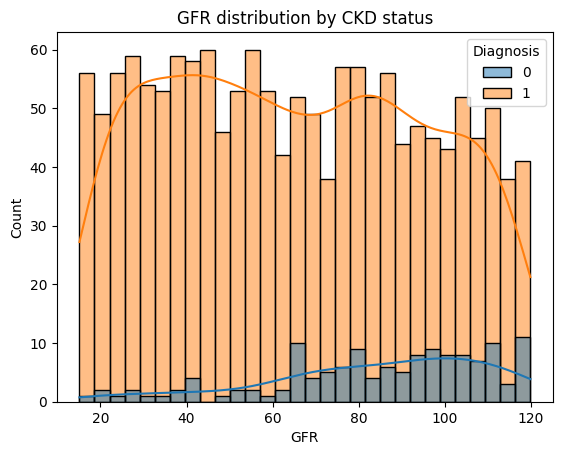

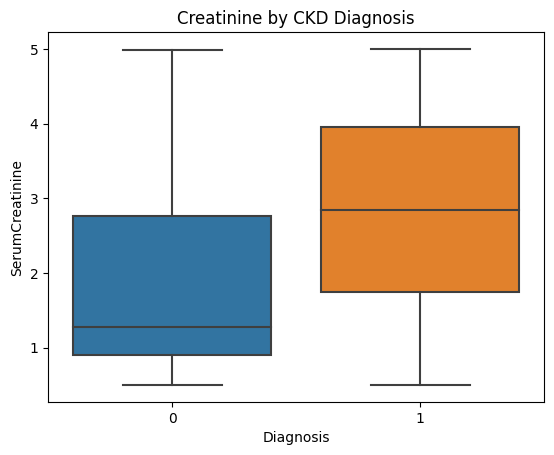

In [7]:
# GFR vs Diagnosis
sns.histplot(data=df, x='GFR', hue='Diagnosis', bins=30, kde=True)
plt.title('GFR distribution by CKD status')
plt.show()
#serum creatinine vs diagnosis
sns.boxplot(data=df, x='Diagnosis', y='SerumCreatinine')
plt.title('Creatinine by CKD Diagnosis')
plt.show()

## EDA: 3. Explore Key Catergorical Features

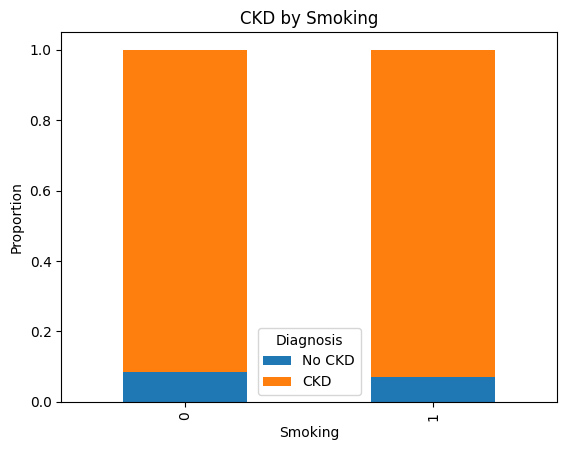

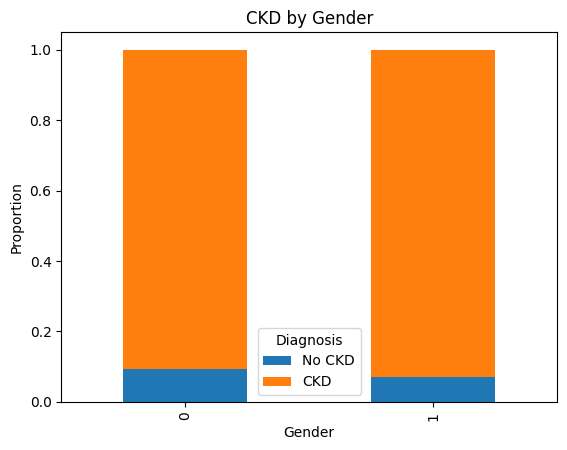

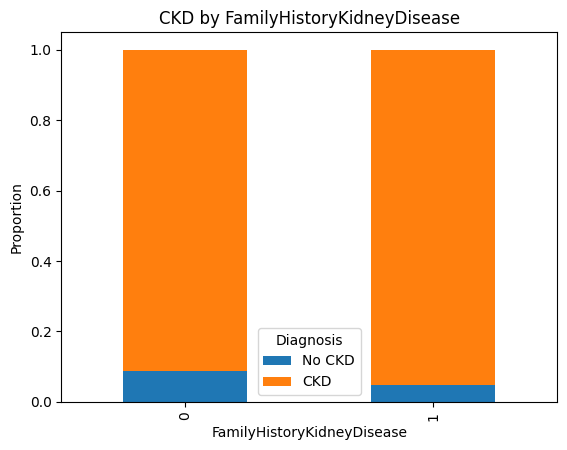

In [8]:
cat_features = ['Smoking', 'Gender', 'FamilyHistoryKidneyDisease']

for col in cat_features:
    ct = pd.crosstab(df[col], df['Diagnosis'], normalize='index')
    ct.plot(kind='bar', stacked=True)
    plt.title(f'CKD by {col}')
    plt.ylabel('Proportion')
    plt.legend(title='Diagnosis', labels=['No CKD', 'CKD'])
    plt.show()

## EDA: 4. Focus Area

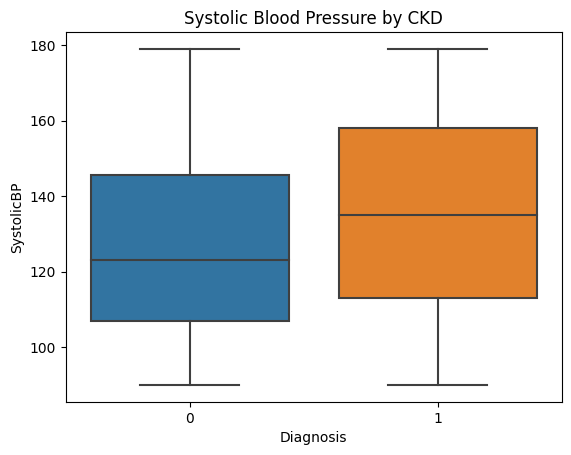

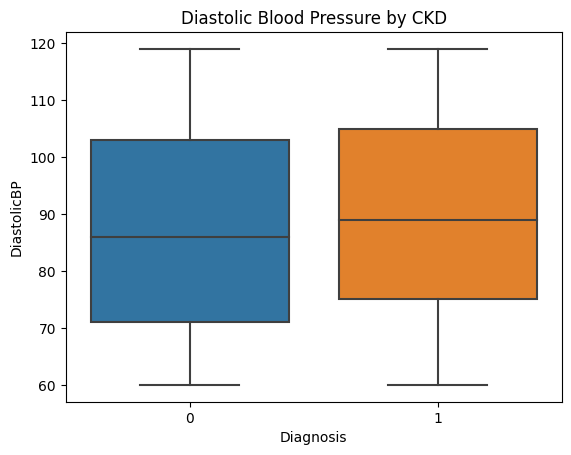

In [9]:
#Blood Pressure (Hypertension Link)
sns.boxplot(data=df, x='Diagnosis', y='SystolicBP')
plt.title('Systolic Blood Pressure by CKD')
plt.show()

sns.boxplot(data=df, x='Diagnosis', y='DiastolicBP')
plt.title('Diastolic Blood Pressure by CKD')
plt.show()

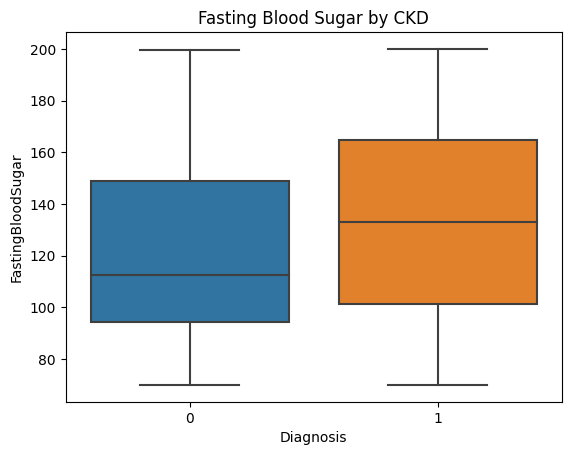

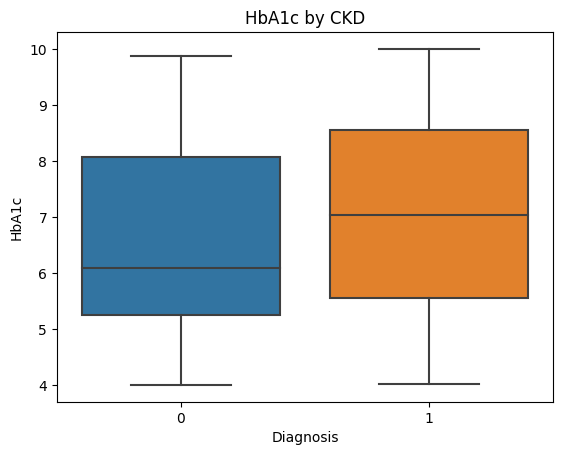

In [10]:
#glucose and diabetes markers
sns.boxplot(data=df, x='Diagnosis', y='FastingBloodSugar')
plt.title('Fasting Blood Sugar by CKD')
plt.show()

sns.boxplot(data=df, x='Diagnosis', y='HbA1c')
plt.title('HbA1c by CKD')
plt.show()

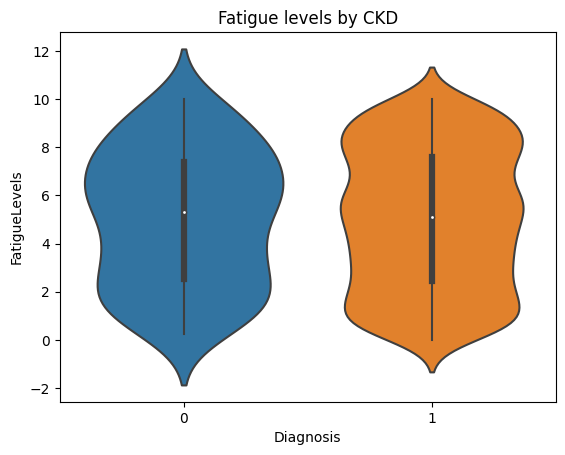

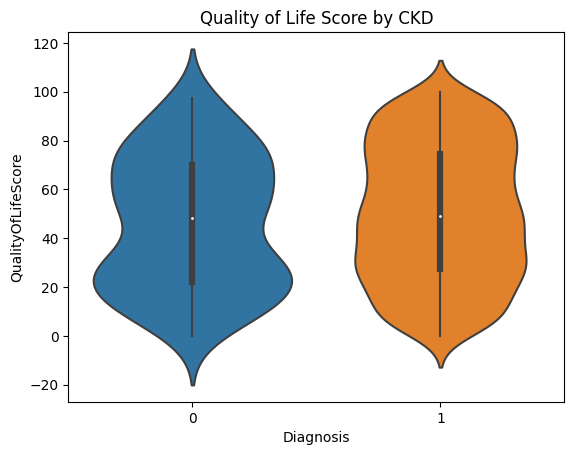

In [11]:
#quality of life and fatigue
sns.violinplot(data=df, x='Diagnosis', y='FatigueLevels')
plt.title('Fatigue levels by CKD')
plt.show()


sns.violinplot(data=df, x='Diagnosis', y='QualityOfLifeScore')
plt.title('Quality of Life Score by CKD')
plt.show()

## EDA: 5. Correlation Heatmap

Top correlated features with CKD Diagnosis:
Diagnosis                     1.000000
SerumCreatinine               0.201125
Itching                       0.100652
FastingBloodSugar             0.095694
MuscleCramps                  0.094811
BUNLevels                     0.093097
ProteinInUrine                0.090014
SystolicBP                    0.083528
HbA1c                         0.059999
BMI                           0.055222
FamilyHistoryKidneyDisease    0.050935
Edema                         0.050857
CholesterolHDL                0.044342
HemoglobinLevels              0.044001
Gender                        0.042239
Name: Diagnosis, dtype: float64

Most negatively correlated (possibly protective):
CholesterolLDL                  -0.006809
Statins                         -0.007134
CholesterolTriglycerides        -0.008489
SerumElectrolytesPhosphorus     -0.011338
AntidiabeticMedications         -0.014582
OccupationalExposureChemicals   -0.015118
WaterQuality                    -0.0

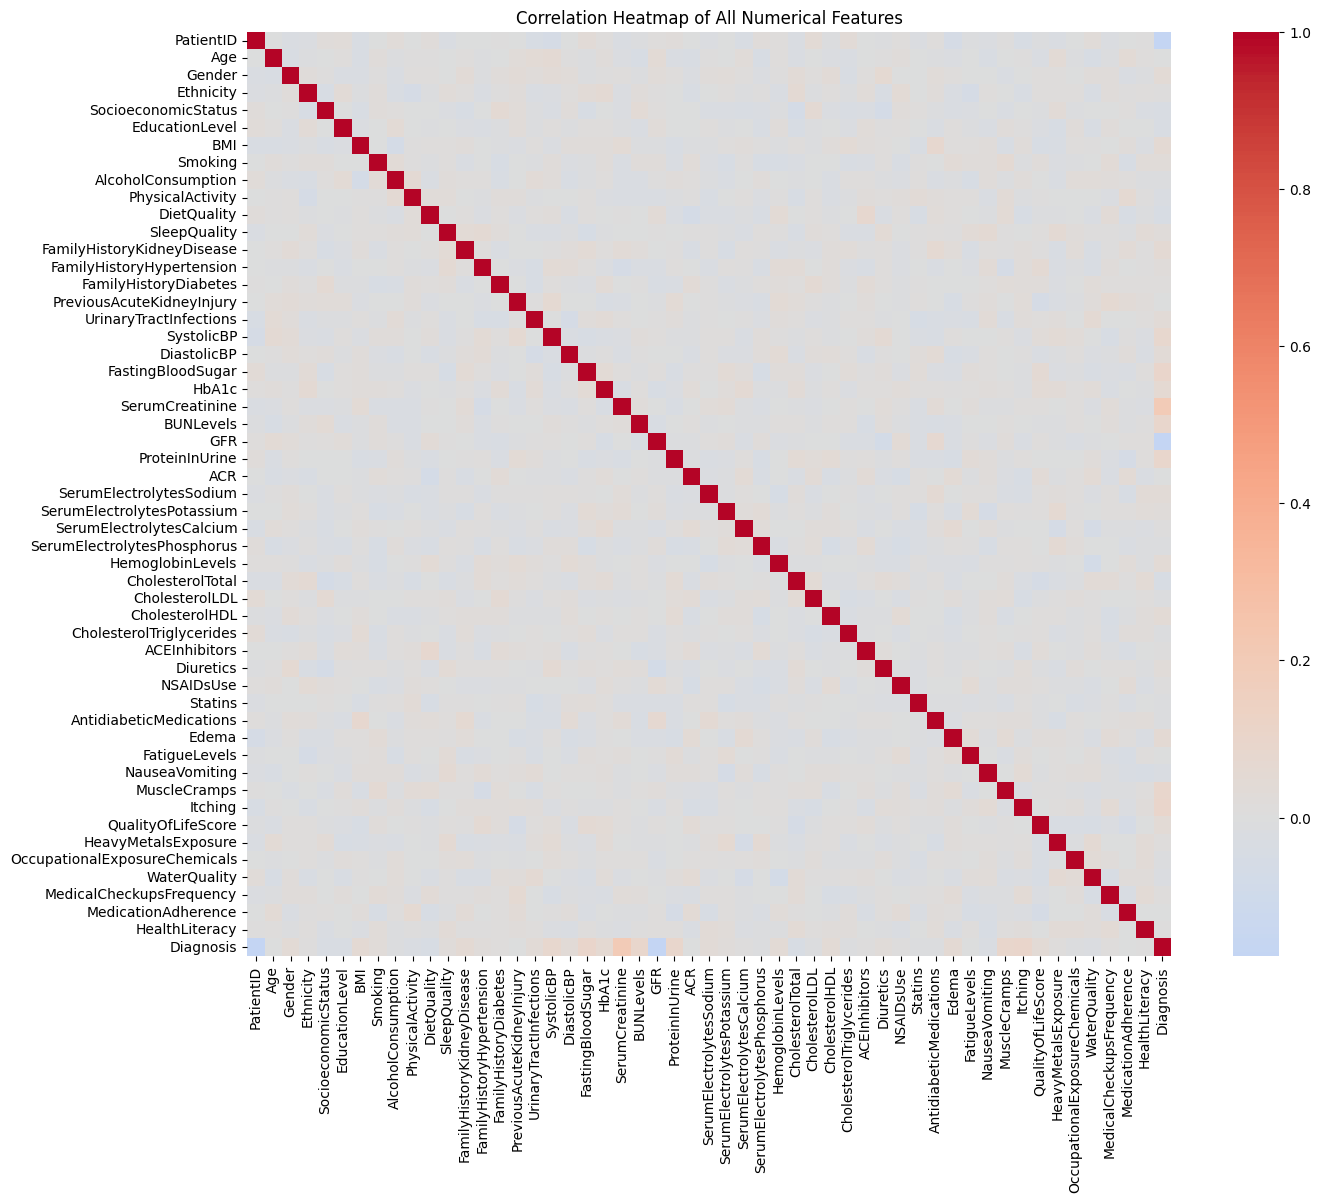

In [12]:
#drop the text-only column
df_cor = df.drop(columns=['DoctorInCharge'], errors='ignore')

#correlation matrix (numeric only)
cor_matrix = df_cor.corr()

#view top correlations with taret
target_cor = cor_matrix['Diagnosis'].sort_values(ascending=False)
print("Top correlated features with CKD Diagnosis:")
print(target_cor.head(15))

print("\nMost negatively correlated (possibly protective):")
print(target_cor.tail(15))

#Full Heatmap
plt.figure(figsize=(16,12))
sns.heatmap(cor_matrix, cmap='coolwarm', annot=False, fmt='.2f', square=True, center=0)
plt.title('Correlation Heatmap of All Numerical Features')
plt.show()

## Feature Engineering: P1

In [13]:
#drop unnecessary columns
df=df.drop(columns=['PatientID','DoctorInCharge'], errors='ignore')

#log-transform serum creatinine to reduce skewness
df['logCreatinine']=np.log1p(df['SerumCreatinine'])

#one-hot encode multi-class categorical variables
df=pd.get_dummies(df,columns=['Ethnicity', 'EducationLevel'], drop_first=True)

#confirm.shape
df.shape

(1659, 57)

## Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

#target and features
X=df.drop(columns=['Diagnosis'])
y=df['Diagnosis']

#split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## Advanced feature engineering

In [16]:
for X_ in [X_train, X_test]:
    #kidney funtion idx
    X_['KidneyStress']=(
        X_['SerumCreatinine']*0.4 +
        X_['ProteinInUrine']*0.3 +
        X_['BUNLevels']*0.2 -
        X_['GFR']*0.1
    )

    #Blood Pressure Pulse Gap
    X_['PulsePressure'] = X_['SystolicBP']-X_['DiastolicBP']

    #Diabetes Control Ratio
    X_['GlucoseToHbA1c']=X_['FastingBloodSugar']/(X_['HbA1c']+1e-3)

    #Comorbidity Count
    X_['ComorbidityCount']=(
        X_['FamilyHistoryKidneyDisease']+
        X_['FamilyHistoryDiabetes']+
        X_['FamilyHistoryHypertension']+
        X_['PreviousAcuteKidneyInjury']+
        X_['UrinaryTractInfections']
    )

    #Health Resilience Score
    X_['ResilienceScore']=(
        X_['PhysicalActivity']+
        X_['DietQuality']+
        X_['SleepQuality']+
        X_['HealthLiteracy']
    )

In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import joblib

X_train = X_train.astype(float)
X_test = X_test.astype(float)


## Defining Models

In [23]:
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=300))
    ]),
    
    "SVM (RBF)": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True))
    ]),
    
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    
    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),
    
    "Naive Bayes": GaussianNB()
}


In [24]:
results = {}
best_score = 0
best_model = None
best_model_name = ""

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc:.4f}")
    
    if acc > best_score:
        best_score = acc
        best_model = model
        best_model_name = name



Training Logistic Regression...
Logistic Regression Accuracy: 0.9157

Training SVM (RBF)...
SVM (RBF) Accuracy: 0.9187

Training Random Forest...
Random Forest Accuracy: 0.9247

Training Gradient Boosting...
Gradient Boosting Accuracy: 0.9036

Training KNN...
KNN Accuracy: 0.9187

Training Naive Bayes...
Naive Bayes Accuracy: 0.8946


In [26]:
joblib.dump(best_model, "CKD.pkl")
print("Best model saved:", best_model_name)

Best model saved: Random Forest
